# Day 7 — Explainability for the Frozen Hybrid NIDS (Final)

This notebook explains the **already-frozen** models from Days 1–6.

It does **not** retrain models, tune thresholds, optimize on test data, or change previous predictions.

Frozen configuration:

- Random Forest threshold = **0.01**
- Isolation Forest threshold = **0.15**
- Hybrid threshold = **0.50**
- Hybrid RF weight = **0.70**
- Hybrid anomaly weight = **0.30**

Explainability goals:

1. Global Random Forest TreeSHAP importance
2. Random Forest built-in importance
3. Frozen-threshold permutation-importance cross-check
4. Local Random Forest explanations for TP/TN/FP/FN
5. Defensible Isolation Forest perturbation explanations
6. Structured evidence suitable for the future LLM narration layer
7. Explicit preservation of the Day 6 CTU-IDSEVAL-6 representation limitation

> Important: the LLM layer is narration/decision-support only. The ML detector remains authoritative.

## 1. Robust project setup

In [1]:
from pathlib import Path
import sys
import os

# ------------------------------------------------------------------
# Robustly locate PROJECT_ROOT.
# Works when the notebook is launched from:
#   PROJECT_ROOT/
#   PROJECT_ROOT/notebooks/
# or another child directory.
# ------------------------------------------------------------------

cwd = Path.cwd().resolve()

candidates = [
    cwd,
    cwd.parent,
    cwd.parent.parent,
]

PROJECT_ROOT = None

for candidate in candidates:
    if (candidate / "src").exists() and (candidate / "models").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Open this notebook from inside the NIDS repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("models exists:", (PROJECT_ROOT / "models").exists())
print("results exists:", (PROJECT_ROOT / "results").exists())

PROJECT_ROOT: C:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-
src exists: True
models exists: True
results exists: True


## 2. Imports and frozen configuration

In [2]:
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

from src.day2.anomaly import (
    AnomalyModel,
    anomaly_scores,
    sample_training_data,
)

from src.day2.hybrid import (
    HybridConfig,
    combine_scores,
)

from src.day7.explainability import (
    deterministic_sample,
    classify_binary_outcomes,
    rf_global_shap_importance,
    rf_local_shap_explanations,
    build_importance_comparison,
    isolation_forest_global_explanation,
    isolation_forest_local_explanations,
    build_llm_evidence,
)

RF_THRESHOLD = 0.01
IF_THRESHOLD = 0.15
HYBRID_THRESHOLD = 0.50

HYBRID_CONFIG = HybridConfig(
    rf_weight=0.7,
    anomaly_weight=0.3,
    threshold=HYBRID_THRESHOLD,
)

RANDOM_STATE = 42

print("Frozen configuration loaded.")
print("RF threshold:", RF_THRESHOLD)
print("IF threshold:", IF_THRESHOLD)
print("Hybrid threshold:", HYBRID_THRESHOLD)
print("Hybrid weights:", 0.7, 0.3)

Frozen configuration loaded.
RF threshold: 0.01
IF threshold: 0.15
Hybrid threshold: 0.5
Hybrid weights: 0.7 0.3


## 3. Locate Day 1 data and metadata

In [3]:
# ------------------------------------------------------------------
# Resolve likely Day 1 artifact paths.
# We support both common layouts used in this project.
# ------------------------------------------------------------------

candidate_train_paths = [
    PROJECT_ROOT / "data" / "processed" / "day1" / "train.parquet",
    PROJECT_ROOT / "data" / "processed" / "train.parquet",
]

candidate_test_paths = [
    PROJECT_ROOT / "data" / "processed" / "day1" / "test.parquet",
    PROJECT_ROOT / "data" / "processed" / "test.parquet",
]

candidate_metadata_paths = [
    PROJECT_ROOT / "models" / "day1" / "metadata.json",
    PROJECT_ROOT / "models" / "day1" / "day1_metadata.json",
    PROJECT_ROOT / "results" / "day1" / "metadata.json",
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

TRAIN_PATH = first_existing(candidate_train_paths)
TEST_PATH = first_existing(candidate_test_paths)
DAY1_METADATA_PATH = first_existing(candidate_metadata_paths)

if TRAIN_PATH is None:
    raise FileNotFoundError(
        "Could not locate the Day 1 training parquet. "
        f"Checked: {[str(p) for p in candidate_train_paths]}"
    )

if TEST_PATH is None:
    raise FileNotFoundError(
        "Could not locate the Day 1 Friday test parquet. "
        f"Checked: {[str(p) for p in candidate_test_paths]}"
    )

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("DAY1_METADATA_PATH:", DAY1_METADATA_PATH)

TRAIN_PATH: C:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\processed\day1\train.parquet
TEST_PATH: C:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\data\processed\day1\test.parquet
DAY1_METADATA_PATH: None


## 4. Load Day 1 train/test data

In [4]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

required_label_cols = {"label_binary"}
missing_labels = required_label_cols - set(train_df.columns)

if missing_labels:
    raise KeyError(
        f"Training dataframe is missing required columns: {sorted(missing_labels)}"
    )

if "label_binary" not in test_df.columns:
    raise KeyError("Friday test dataframe is missing label_binary.")

train_df shape: (1796986, 75)
test_df shape: (516824, 75)


## 5. Resolve the 58 frozen feature names

In [5]:
feature_names = None

# Preferred: Day 1 metadata, because Day 2 originally read feature_names
# from the Day 1 metadata.
if DAY1_METADATA_PATH is not None:
    day1_metadata = json.loads(DAY1_METADATA_PATH.read_text(encoding="utf-8"))
    feature_names = day1_metadata.get("feature_names")

# Fallback: sklearn feature_names_in_ after the RF is loaded below.
# We defer failure until the RF cell if metadata is unavailable.

print(
    "Feature names from metadata:",
    None if feature_names is None else len(feature_names)
)

Feature names from metadata: None


## 6. Load the frozen Random Forest

In [6]:
candidate_rf_paths = [
    PROJECT_ROOT / "models" / "day1" / "random_forest_baseline.joblib",
    PROJECT_ROOT / "models" / "day1" / "random_forest.joblib",
]

RF_MODEL_PATH = first_existing(candidate_rf_paths)

if RF_MODEL_PATH is None:
    raise FileNotFoundError(
        "Could not locate the frozen Day 1 Random Forest. "
        f"Checked: {[str(p) for p in candidate_rf_paths]}"
    )

rf_model = joblib.load(RF_MODEL_PATH)

if feature_names is None:
    if hasattr(rf_model, "feature_names_in_"):
        feature_names = list(rf_model.feature_names_in_)
    else:
        raise RuntimeError(
            "Could not recover the 58 feature names from either "
            "Day 1 metadata or the Random Forest artifact."
        )
else:
    feature_names = list(feature_names)

print("RF model:", type(rf_model))
print("RF model path:", RF_MODEL_PATH)
print("Frozen feature count:", len(feature_names))

if len(feature_names) != 58:
    print(
        "WARNING: expected 58 frozen CIC-IDS2017 features, "
        f"but found {len(feature_names)}."
    )

RF model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
RF model path: C:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\models\day1\random_forest_baseline.joblib
Frozen feature count: 58


## 7. Prepare Day 1 feature matrices using training medians

In [7]:
missing_train = [c for c in feature_names if c not in train_df.columns]
missing_test = [c for c in feature_names if c not in test_df.columns]

if missing_train:
    raise KeyError(f"Training dataframe missing frozen features: {missing_train}")

if missing_test:
    raise KeyError(f"Friday test dataframe missing frozen features: {missing_test}")

# Day 1 / Day 2 RF preprocessing uses training-data medians.
train_medians_full = train_df[feature_names].median(numeric_only=True)

X_train_clean = train_df[feature_names].copy().fillna(train_medians_full)
X_test_clean = test_df[feature_names].copy().fillna(train_medians_full)

y_train = train_df["label_binary"].astype(int)
y_test = test_df["label_binary"].astype(int)

print("X_train_clean:", X_train_clean.shape)
print("X_test_clean:", X_test_clean.shape)
print("Remaining NaN train:", int(X_train_clean.isna().sum().sum()))
print("Remaining NaN test:", int(X_test_clean.isna().sum().sum()))

X_train_clean: (1796986, 58)
X_test_clean: (516824, 58)
Remaining NaN train: 0
Remaining NaN test: 0


## 8. Load and reconstruct the frozen Day 2 Isolation Forest wrapper

In [8]:
IF_MODEL_PATH = PROJECT_ROOT / "models" / "day2" / "isolation_forest.joblib"
DAY2_METADATA_PATH = PROJECT_ROOT / "models" / "day2" / "day2_metadata.json"

if not IF_MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing frozen IF artifact: {IF_MODEL_PATH}")

if not DAY2_METADATA_PATH.exists():
    raise FileNotFoundError(f"Missing Day 2 metadata: {DAY2_METADATA_PATH}")

day2_metadata = json.loads(
    DAY2_METADATA_PATH.read_text(encoding="utf-8")
)

raw_if_model = joblib.load(IF_MODEL_PATH)

print("Raw saved IF type:", type(raw_if_model))

# ------------------------------------------------------------------
# Reconstruct the exact metadata wrapper used by src.day2.anomaly_scores.
#
# IMPORTANT:
# - sample_training_data is deterministic with random_state=42.
# - This reproduces the Day 2 sample only to recover sample medians.
# - The frozen sklearn IsolationForest is NOT fitted/retrained here.
# ------------------------------------------------------------------

if_config = day2_metadata["isolation_forest_config"]
if_sample_config = day2_metadata["isolation_forest_sample"]

anomaly_sample = sample_training_data(
    train_df,
    feature_names,
    n_samples=int(if_sample_config["n_samples"]),
    benign_fraction=float(if_sample_config["benign_fraction_requested"]),
    random_state=int(if_sample_config["random_state"]),
)

if_model = AnomalyModel(
    model=raw_if_model,
    feature_names=list(feature_names),
    train_medians=anomaly_sample.X.median(numeric_only=True),
    contamination=float(if_config["contamination"]),
    n_estimators=int(if_config["n_estimators"]),
    random_state=int(if_config["random_state"]),
    n_training_samples=int(if_sample_config["n_samples"]),
)

print("Wrapper type:", type(if_model))
print("Underlying model:", type(if_model.model))
print("Feature count:", len(if_model.feature_names))
print("Training sample rows used to recover wrapper medians:", len(anomaly_sample.X))

assert isinstance(if_model, AnomalyModel)
assert len(if_model.feature_names) == len(feature_names)

Raw saved IF type: <class 'sklearn.ensemble._iforest.IsolationForest'>
Wrapper type: <class 'src.day2.anomaly.AnomalyModel'>
Underlying model: <class 'sklearn.ensemble._iforest.IsolationForest'>
Feature count: 58
Training sample rows used to recover wrapper medians: 100000


### Why this wrapper reconstruction is valid

The Day 2 saved artifact contains the already-fitted sklearn `IsolationForest`, but `src.day2.anomaly.anomaly_scores()` expects the project's `AnomalyModel` wrapper.

The original Day 2 wrapper also stored:

- the 58 feature names
- the deterministic anomaly-training sample medians
- contamination
- estimator count
- random state
- number of training samples

This cell recreates only that metadata wrapper. It does **not** call `fit()` and therefore does **not** retrain or alter the frozen Isolation Forest.

## 9. Reproduce frozen Friday predictions

In [9]:
rf_proba = rf_model.predict_proba(X_test_clean)[:, 1]
rf_pred = (rf_proba >= RF_THRESHOLD).astype(int)

# Project Day 2 normalized anomaly score in [0,1].
if_score = anomaly_scores(if_model, X_test_clean)
if_pred = (if_score >= IF_THRESHOLD).astype(int)

hybrid_score = combine_scores(
    rf_proba,
    if_score,
    HYBRID_CONFIG,
)
hybrid_pred = (hybrid_score >= HYBRID_THRESHOLD).astype(int)

print("RF predicted attacks:", int(rf_pred.sum()))
print("IF predicted attacks:", int(if_pred.sum()))
print("Hybrid predicted attacks:", int(hybrid_pred.sum()))

print()
print("RF score range:", float(np.min(rf_proba)), float(np.max(rf_proba)))
print("IF score range:", float(np.min(if_score)), float(np.max(if_score)))
print("Hybrid score range:", float(np.min(hybrid_score)), float(np.max(hybrid_score)))

RF predicted attacks: 140724
IF predicted attacks: 226854
Hybrid predicted attacks: 160

RF score range: 0.0 0.9979607621839918
IF score range: 0.0 1.0
Hybrid score range: 0.0 0.874786253331503


## 10. Optional frozen-metric sanity check

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def metric_summary(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

print("RF:", metric_summary(y_test, rf_pred))
print("IF:", metric_summary(y_test, if_pred))
print("Hybrid:", metric_summary(y_test, hybrid_pred))

RF: {'precision': np.float64(0.8234700548591569), 'recall': np.float64(0.8818556089097233), 'f1': np.float64(0.8516633533114566), 'tn': 360575, 'fp': 24842, 'fn': 15525, 'tp': 115882}
IF: {'precision': np.float64(0.4416981847355568), 'recall': np.float64(0.7625240664500369), 'f1': np.float64(0.5593743109074111), 'tn': 258764, 'fp': 126653, 'fn': 31206, 'tp': 100201}
Hybrid: {'precision': np.float64(0.49375), 'recall': np.float64(0.0006011856293804745), 'f1': np.float64(0.0012009090425410627), 'tn': 385336, 'fp': 81, 'fn': 131328, 'tp': 79}


Expected research interpretation from earlier frozen Friday evaluation:

- RF should remain the strongest of the three detectors.
- Isolation Forest should have substantially higher false-positive behavior.
- Hybrid at the frozen 0.50 threshold should have very low Friday recall.

If your reproduced numbers differ materially from the saved Day 2 results, stop and investigate preprocessing/model-loading consistency rather than tuning thresholds.

## 11. Deterministic explanation sample

In [11]:
EXPLANATION_SAMPLE_SIZE = min(10_000, len(X_test_clean))

sample_indices = deterministic_sample(
    y_test,
    n_samples=EXPLANATION_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_explain = X_test_clean.loc[sample_indices]
y_explain = y_test.loc[sample_indices]

rf_proba_explain = pd.Series(
    rf_proba,
    index=X_test_clean.index,
).loc[sample_indices]

rf_pred_explain = pd.Series(
    rf_pred,
    index=X_test_clean.index,
).loc[sample_indices]

if_score_explain = pd.Series(
    if_score,
    index=X_test_clean.index,
).loc[sample_indices]

if_pred_explain = pd.Series(
    if_pred,
    index=X_test_clean.index,
).loc[sample_indices]

print("Explanation sample rows:", len(X_explain))
print("Attack rows:", int(y_explain.sum()))
print("Benign rows:", int((y_explain == 0).sum()))

Explanation sample rows: 10000
Attack rows: 5000
Benign rows: 5000


## Why explainability matters in this NIDS

High detection performance alone does not explain **why** the model raised an alert. In a network intrusion setting, an analyst should be able to inspect which traffic characteristics influenced the detector and whether those characteristics are plausible indicators of malicious behavior.

Day 7 therefore treats explainability as an **audit and decision-support layer** over the already-frozen detector. It is not another model-selection stage.

The explanation layer is used to:

- identify globally influential traffic features;
- explain individual correct and incorrect detections;
- compare multiple importance methods rather than relying on a single explanation technique;
- expose uncertainty, disagreement, and representation limitations;
- create structured evidence that can later be narrated by the LLM layer.

No explanation result is used to retrain the detector, tune thresholds, or change Day 1–6 predictions.

## 12. Random Forest global TreeSHAP importance

In [12]:
# SHAP can be computationally expensive.
# Use a deterministic subset of the explanation sample.
SHAP_SAMPLE_SIZE = min(2_000, len(X_explain))

shap_indices = deterministic_sample(
    y_explain,
    n_samples=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_shap = X_explain.loc[shap_indices]

rf_shap_importance, rf_shap_values = rf_global_shap_importance(
    rf_model,
    X_shap,
    feature_names,
)

display(rf_shap_importance.head(20))

c:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_abs_shap,rank,shap_rank
0,Init Bwd Win Bytes,0.071697,1,1
1,Bwd Packet Length Std,0.049289,2,2
2,Fwd Packet Length Max,0.042963,3,3
3,Fwd Packet Length Std,0.033338,4,4
4,Bwd Packet Length Mean,0.027950,5,5
5,Packet Length Std,0.023196,6,6
6,Bwd Packets Length Total,0.021919,7,7
7,Bwd Header Length,0.021703,8,8
8,Packet Length Variance,0.020131,9,9
9,Packet Length Mean,0.019137,10,10


### Presentation plot — top Random Forest SHAP features

This plot summarizes the features with the largest **mean absolute SHAP contribution**. Larger values mean the feature had a stronger average influence on the Random Forest output across the explanation sample. This shows model influence, not causality.

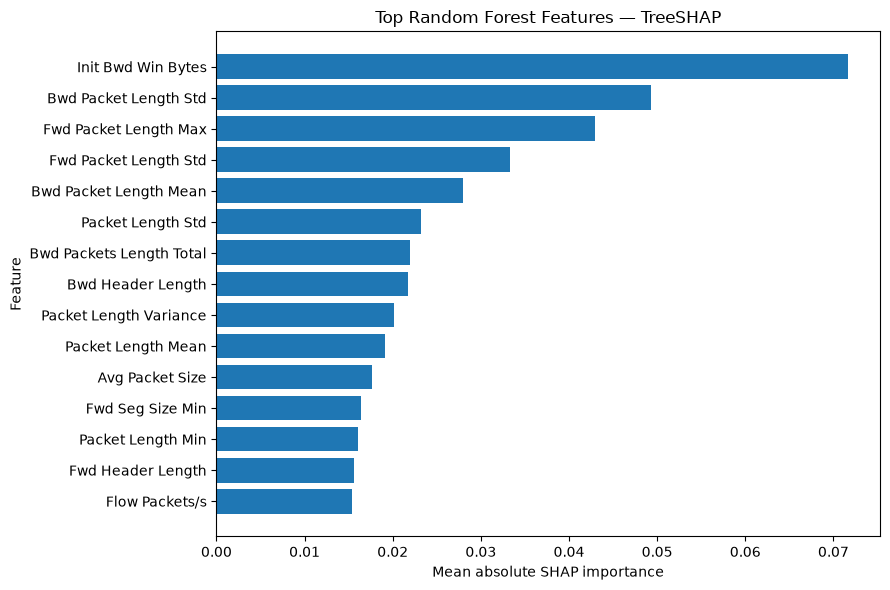

In [13]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = rf_shap_importance.head(top_n).copy()

# Identify the numeric importance column robustly.
candidate_cols = [
    c for c in plot_df.columns
    if c != "feature" and pd.api.types.is_numeric_dtype(plot_df[c])
]

if not candidate_cols:
    raise ValueError("Could not identify the numeric SHAP importance column.")

shap_importance_col = candidate_cols[0]

plot_df = plot_df.sort_values(shap_importance_col, ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df[shap_importance_col])
plt.xlabel("Mean absolute SHAP importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Features — TreeSHAP")
plt.tight_layout()
plt.show()

## 13. Random Forest built-in feature importance

In [14]:
rf_builtin_importance = pd.DataFrame({
    "feature": feature_names,
    "rf_builtin_importance": rf_model.feature_importances_,
})

rf_builtin_importance["builtin_rank"] = (
    rf_builtin_importance["rf_builtin_importance"]
    .rank(ascending=False, method="min")
)

rf_builtin_importance = rf_builtin_importance.sort_values(
    ["rf_builtin_importance", "feature"],
    ascending=[False, True],
    ignore_index=True,
)

display(rf_builtin_importance.head(20))

,feature,rf_builtin_importance,builtin_rank
0,Packet Length Max,0.100126,1.0
1,Bwd Packet Length Std,0.097290,2.0
2,Packet Length Variance,0.072273,3.0
3,Packet Length Std,0.061462,4.0
4,Packet Length Mean,0.061202,5.0
5,Bwd Packet Length Mean,0.055361,6.0
6,Bwd Packet Length Max,0.053883,7.0
7,Flow Packets/s,0.050631,8.0
8,Avg Packet Size,0.034910,9.0
9,Fwd IAT Max,0.032136,10.0


## 14. Permutation importance cross-check

In [15]:
# ------------------------------------------------------------------
# Frozen-threshold permutation importance
#
# sklearn's default classification scorers would call rf_model.predict(),
# which uses the model's default class decision rather than this project's
# frozen RF probability threshold of 0.01.
#
# Therefore we compute permutation importance manually using the actual
# frozen detector:
#
#     predict_proba(X)[:, 1] >= RF_THRESHOLD
#
# This preserves the Day 1/Day 2 experimental protocol.
# ------------------------------------------------------------------

PERM_SAMPLE_SIZE = min(5_000, len(X_explain))

perm_indices = deterministic_sample(
    y_explain,
    n_samples=PERM_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_perm = X_explain.loc[perm_indices].copy()
y_perm = y_explain.loc[perm_indices].astype(int).to_numpy()

baseline_proba = rf_model.predict_proba(X_perm)[:, 1]
baseline_pred = (baseline_proba >= RF_THRESHOLD).astype(int)
baseline_f1 = f1_score(y_perm, baseline_pred, zero_division=0)

rng = np.random.RandomState(RANDOM_STATE)
n_repeats = 5
rows = []

for feature in feature_names:
    drops = []

    for repeat in range(n_repeats):
        X_shuffled = X_perm.copy()
        shuffled_values = X_shuffled[feature].to_numpy(copy=True)
        rng.shuffle(shuffled_values)
        X_shuffled[feature] = shuffled_values

        shuffled_proba = rf_model.predict_proba(X_shuffled)[:, 1]
        shuffled_pred = (shuffled_proba >= RF_THRESHOLD).astype(int)
        shuffled_f1 = f1_score(y_perm, shuffled_pred, zero_division=0)

        drops.append(baseline_f1 - shuffled_f1)

    rows.append({
        "feature": feature,
        "permutation_importance_mean": float(np.mean(drops)),
        "permutation_importance_std": float(np.std(drops, ddof=0)),
    })

rf_permutation_importance = pd.DataFrame(rows)

rf_permutation_importance["permutation_rank"] = (
    rf_permutation_importance["permutation_importance_mean"]
    .rank(ascending=False, method="min")
)

rf_permutation_importance = rf_permutation_importance.sort_values(
    ["permutation_importance_mean", "feature"],
    ascending=[False, True],
    ignore_index=True,
)

print("Frozen RF threshold:", RF_THRESHOLD)
print("Baseline F1 on permutation sample:", baseline_f1)
display(rf_permutation_importance.head(20))

Frozen RF threshold: 0.01
Baseline F1 on permutation sample: 0.8989919769594733


,feature,permutation_importance_mean,permutation_importance_std,permutation_rank
0,Bwd Packet Length Mean,0.218105,0.003113,1.0
1,Packet Length Max,0.194357,0.002035,2.0
2,Packet Length Mean,0.187933,0.002610,3.0
3,Fwd Packet Length Mean,0.177323,0.002389,4.0
4,Bwd Packets Length Total,0.162593,0.002966,5.0
5,Avg Packet Size,0.160218,0.000597,6.0
6,Bwd Packet Length Max,0.154581,0.001816,7.0
7,Fwd Packet Length Max,0.150357,0.002569,8.0
8,Packet Length Std,0.135508,0.003836,9.0
9,Packet Length Variance,0.134796,0.004309,10.0


## 15. Compare the three RF importance methods

In [16]:
rf_importance_comparison = build_importance_comparison(
    rf_shap_importance,
    rf_builtin_importance,
    rf_permutation_importance,
)

display(rf_importance_comparison.head(25))

,feature,mean_abs_shap,shap_rank,rf_builtin_importance,builtin_rank,permutation_importance_mean,permutation_importance_std,permutation_rank,shap_normalized,builtin_normalized,permutation_normalized
0,Init Bwd Win Bytes,0.071697,1,0.016058,20.0,0.102974,0.001972,16.0,0.116913,0.016058,0.024749
1,Bwd Packet Length Std,0.049289,2,0.097290,2.0,0.109162,0.003510,14.0,0.080374,0.097290,0.026236
2,Fwd Packet Length Max,0.042963,3,0.011004,24.0,0.150357,0.002569,8.0,0.070058,0.011004,0.036138
3,Fwd Packet Length Std,0.033338,4,0.005315,36.0,0.046875,0.004395,38.0,0.054362,0.005315,0.011266
4,Bwd Packet Length Mean,0.027950,5,0.055361,6.0,0.218105,0.003113,1.0,0.045576,0.055361,0.052420
5,Packet Length Std,0.023196,6,0.061462,4.0,0.135508,0.003836,9.0,0.037824,0.061462,0.032569
6,Bwd Packets Length Total,0.021919,7,0.028931,11.0,0.162593,0.002966,5.0,0.035743,0.028931,0.039078
7,Bwd Header Length,0.021703,8,0.012697,22.0,0.105755,0.001811,15.0,0.035390,0.012697,0.025418
8,Packet Length Variance,0.020131,9,0.072273,3.0,0.134796,0.004309,10.0,0.032827,0.072273,0.032398
9,Packet Length Mean,0.019137,10,0.061202,5.0,0.187933,0.002610,3.0,0.031206,0.061202,0.045169


### How to interpret SHAP, built-in importance, and permutation importance

These three methods answer related but different questions:

- **TreeSHAP:** Which features contribute most strongly to the Random Forest's output?
- **Built-in RF importance:** Which features were most useful to the forest's decision-tree splits?
- **Frozen-threshold permutation importance:** How much does the detector's **actual F1 at threshold 0.01** deteriorate when one feature is randomly disrupted?

Agreement between the methods strengthens confidence that a feature is genuinely important to the fitted detector. Disagreement is also meaningful: it can indicate correlated features, interaction effects, split-importance bias, or a feature that influences scores without strongly changing the final thresholded decision.

For this project, permutation importance is deliberately calculated using `predict_proba >= 0.01` rather than sklearn's default `predict()` classification rule, because **0.01 is the frozen RF decision threshold used in the research experiment**.

Interpretation guidance:

- TreeSHAP estimates how strongly features contribute to model outputs.
- Random Forest built-in importance reflects split-based importance and may favor continuous/high-cardinality features.
- Permutation importance measures performance degradation when a feature is shuffled.
- Agreement across methods increases confidence that a feature is genuinely important to the fitted model.
- Disagreement is itself informative and should be reported rather than hidden.
- None of these methods establishes causality.

## 16. Random Forest local TP/TN/FP/FN explanations

In [17]:
rf_outcomes = classify_binary_outcomes(
    y_true=y_test,
    y_pred=rf_pred,
    index=X_test_clean.index,
)

print({k: len(v) for k, v in rf_outcomes.items()})

rf_local = rf_local_shap_explanations(
    model=rf_model,
    X=X_test_clean,
    y_true=y_test,
    y_pred=rf_pred,
    probabilities=rf_proba,
    threshold=RF_THRESHOLD,
    feature_names=feature_names,
    outcomes=rf_outcomes,
    max_per_category=1,
    dataset="CIC-IDS2017-Friday",
    top_k=10,
)

rf_local

{'TP': 115882, 'TN': 360575, 'FP': 24842, 'FN': 15525}


[{'detector': 'random_forest',
  'dataset': 'CIC-IDS2017-Friday',
  'sample_index': 53647,
  'outcome': 'TP',
  'true_label': 1,
  'prediction': 'attack',
  'prediction_binary': 1,
  'score': 0.010175522684757417,
  'score_semantics': 'random_forest_attack_probability',
  'threshold': 0.01,
  'evidence_type': 'shap',
  'top_positive_contributors': [{'feature': 'Fwd IAT Min',
    'value': 949.0,
    'contribution': 0.004806559033825225},
   {'feature': 'Init Bwd Win Bytes',
    'value': 237.0,
    'contribution': 0.004124847868476403},
   {'feature': 'Packet Length Min',
    'value': 0.0,
    'contribution': 0.003941541384246908},
   {'feature': 'Bwd Packet Length Min',
    'value': 0.0,
    'contribution': 0.002978272028597162},
   {'feature': 'ACK Flag Count',
    'value': 0.0,
    'contribution': 0.0018090202016126523},
   {'feature': 'Protocol',
    'value': 6.0,
    'contribution': 0.0016174268684551933},
   {'feature': 'Flow IAT Min',
    'value': 123.0,
    'contribution': 0.0012

## 17. Isolation Forest global perturbation explanation

In [18]:
# Use a smaller subset because one-feature perturbation evaluates the
# Isolation Forest repeatedly across all 58 features.
IF_EXPLAIN_SAMPLE_SIZE = min(2_000, len(X_explain))

if_explain_indices = deterministic_sample(
    y_explain,
    n_samples=IF_EXPLAIN_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_if_explain = X_explain.loc[if_explain_indices]

# Pass the wrapper; the Day 7 helper safely uses its underlying frozen sklearn IF.
if_global_importance = isolation_forest_global_explanation(
    model=if_model,
    X=X_if_explain,
    feature_names=feature_names,
    random_state=RANDOM_STATE,
)

display(if_global_importance.head(20))

,feature,importance,method,rank
0,Packet Length Variance,0.007988,one_feature_at_a_time_raw_anomaly_score_pertur...,1
1,Bwd Packet Length Mean,0.006265,one_feature_at_a_time_raw_anomaly_score_pertur...,2
2,Packet Length Std,0.003798,one_feature_at_a_time_raw_anomaly_score_pertur...,3
3,Packet Length Max,0.003768,one_feature_at_a_time_raw_anomaly_score_pertur...,4
4,Bwd Packet Length Max,0.003756,one_feature_at_a_time_raw_anomaly_score_pertur...,5
5,Bwd Packet Length Std,0.003405,one_feature_at_a_time_raw_anomaly_score_pertur...,6
6,Packet Length Mean,0.003160,one_feature_at_a_time_raw_anomaly_score_pertur...,7
7,URG Flag Count,0.002367,one_feature_at_a_time_raw_anomaly_score_pertur...,8
8,ACK Flag Count,0.002230,one_feature_at_a_time_raw_anomaly_score_pertur...,9
9,Protocol,0.001816,one_feature_at_a_time_raw_anomaly_score_pertur...,10


### Presentation plot — top Isolation Forest perturbation features

This plot shows which features produce the largest average change in the underlying Isolation Forest anomaly function when individually replaced by a reference median.

It is a perturbation-based explanation of the frozen anomaly detector. It must **not** be described as a probability, causal effect, or SHAP value.

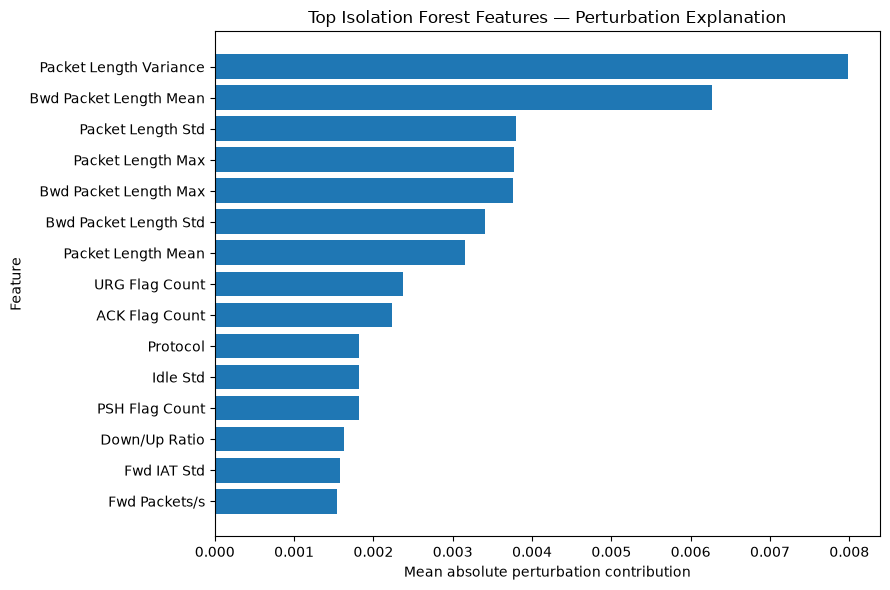

In [19]:
top_n = 15
plot_df = if_global_importance.head(top_n).copy()

candidate_cols = [
    c for c in plot_df.columns
    if c != "feature" and pd.api.types.is_numeric_dtype(plot_df[c])
]

if not candidate_cols:
    raise ValueError("Could not identify the numeric IF importance column.")

if_importance_col = candidate_cols[0]

plot_df = plot_df.sort_values(if_importance_col, ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df[if_importance_col])
plt.xlabel("Mean absolute perturbation contribution")
plt.ylabel("Feature")
plt.title("Top Isolation Forest Features — Perturbation Explanation")
plt.tight_layout()
plt.show()

### Isolation Forest explanation semantics

The Isolation Forest explanation is deliberately **not presented as DIFFI**.

For each feature, one-feature-at-a-time perturbation replaces that feature with a reference median and measures the change in the underlying frozen Isolation Forest anomaly score.

This is:

- model-based
- deterministic
- non-causal
- not a probability explanation
- potentially incomplete when strong feature interactions exist

The frozen **detection** decision still uses the project's normalized Day 2 anomaly score and frozen threshold 0.15.

## 18. Isolation Forest local TP/TN/FP/FN explanations

In [20]:
if_outcomes = classify_binary_outcomes(
    y_true=y_test,
    y_pred=if_pred,
    index=X_test_clean.index,
)

print({k: len(v) for k, v in if_outcomes.items()})

if_local = isolation_forest_local_explanations(
    model=if_model,
    X=X_test_clean,
    y_true=y_test,
    predictions=if_pred,
    anomaly_score=if_score,
    threshold=IF_THRESHOLD,
    feature_names=feature_names,
    outcomes=if_outcomes,
    max_per_category=1,
    random_state=RANDOM_STATE,
    dataset="CIC-IDS2017-Friday",
    top_k=10,
)

if_local

{'TP': 100201, 'TN': 258764, 'FP': 126653, 'FN': 31206}


[{'detector': 'isolation_forest',
  'dataset': 'CIC-IDS2017-Friday',
  'sample_index': 23158,
  'outcome': 'TP',
  'true_label': 1,
  'prediction': 'attack',
  'prediction_binary': 1,
  'anomaly_score': 0.19963875946658607,
  'score_semantics': 'normalized_anomaly_score_not_probability',
  'threshold': 0.15,
  'evidence_type': 'one_feature_at_a_time_raw_anomaly_score_perturbation',
  'top_contributors': [{'feature': 'Packet Length Min',
    'value': 0.0,
    'contribution': -0.013825063781640112},
   {'feature': 'PSH Flag Count',
    'value': 1.0,
    'contribution': -0.006658606989308924},
   {'feature': 'Init Fwd Win Bytes',
    'value': 29200.0,
    'contribution': 0.005647081802324039},
   {'feature': 'Fwd Packet Length Min',
    'value': 0.0,
    'contribution': -0.00466530216580574},
   {'feature': 'Flow IAT Mean',
    'value': 3541331.75,
    'contribution': 0.004490483395664768},
   {'feature': 'Idle Max',
    'value': 10200000.0,
    'contribution': -0.004312276922068703},
   

## 19. Day 6 CTU-IDSEVAL-6 representation limitation

In [21]:
day6_representation_summary = {
    "dataset": "CTU-IDSEVAL-6",
    "mapped_feature_count": 9,
    "total_frozen_feature_count": 58,
    "training_median_imputed_feature_count": 49,
    "adapter_candidate_features": 11,
    "duration_conversion": "Zeek seconds -> CIC Flow Duration microseconds (x1,000,000)",
    "background_policy": "exclude",
    "rows_used_after_background_exclusion": 253_539,
    "benign_rows": 78_742,
    "attack_rows": 174_797,
}

day6_representation_summary

{'dataset': 'CTU-IDSEVAL-6',
 'mapped_feature_count': 9,
 'total_frozen_feature_count': 58,
 'training_median_imputed_feature_count': 49,
 'adapter_candidate_features': 11,
 'duration_conversion': 'Zeek seconds -> CIC Flow Duration microseconds (x1,000,000)',
 'background_policy': 'exclude',
 'rows_used_after_background_exclusion': 253539,
 'benign_rows': 78742,
 'attack_rows': 174797}

The most important limitation for Day 6 explanations is representational mismatch:

- only **9/58** frozen CIC-IDS2017 model features were ultimately mapped
- **49/58** were filled using CIC-IDS2017 training medians
- therefore many model inputs were not directly observed from CTU-IDSEVAL-6

Any future explanation layer must explicitly distinguish:

- directly mapped/derived external features
- training-median-imputed features
- unknown provenance

It must not describe an imputed value as if it were directly observed in CTU traffic.

## Explainability limitations

The Day 7 explanation results should be interpreted with the same care as the detector results.

**TreeSHAP limitations:** SHAP describes the fitted Random Forest, not the true causal mechanism of an intrusion. Correlated flow features can distribute importance across several variables, and a high SHAP contribution does not prove that a feature caused malicious behavior.

**Built-in importance limitations:** tree split importance can be biased toward features that offer many possible split points and can divide importance among correlated predictors.

**Permutation importance limitations:** shuffling a correlated feature may underestimate its importance because another correlated feature can partially replace its information. In this notebook, the method is nevertheless aligned with the experimental detector by evaluating F1 at the frozen RF threshold of 0.01.

**Isolation Forest explanation limitations:** the one-feature-at-a-time perturbation method is a model-behavior explanation, not a probability attribution and not a causal explanation. Interactions between several anomalous features may not be fully captured.

**External-dataset limitation:** explanation quality depends on input representation quality. This is especially important for CTU-IDSEVAL-6, where only 9 of the 58 frozen CIC-IDS2017 features were ultimately mapped and 49 were filled using CIC-IDS2017 training medians.

These limitations should be surfaced to the future LLM explanation layer rather than hidden.

## 20. Build structured evidence for the future LLM layer

In [22]:
llm_evidence = build_llm_evidence(
    rf_local_explanations=rf_local,
    if_local_explanations=if_local,
    rf_threshold=RF_THRESHOLD,
    if_threshold=IF_THRESHOLD,
    hybrid_threshold=HYBRID_THRESHOLD,
    hybrid_weights={
        "rf": 0.7,
        "anomaly": 0.3,
    },
    day6_summary=day6_representation_summary,
    day6_mapped_feature_count=9,
    day6_imputed_feature_count=49,
)

print("Evidence records:", len(llm_evidence))

if llm_evidence:
    print(json.dumps(llm_evidence[0], indent=2, default=str))

Evidence records: 8
{
  "detector": "random_forest",
  "dataset": "CIC-IDS2017-Friday",
  "sample_index": 53647,
  "outcome": "TP",
  "true_label": 1,
  "prediction": "attack",
  "prediction_binary": 1,
  "score": 0.010175522684757417,
  "score_semantics": "random_forest_attack_probability",
  "threshold": 0.01,
  "evidence_type": "shap",
  "top_positive_contributors": [
    {
      "feature": "Fwd IAT Min",
      "value": 949.0,
      "contribution": 0.004806559033825225
    },
    {
      "feature": "Init Bwd Win Bytes",
      "value": 237.0,
      "contribution": 0.004124847868476403
    },
    {
      "feature": "Packet Length Min",
      "value": 0.0,
      "contribution": 0.003941541384246908
    },
    {
      "feature": "Bwd Packet Length Min",
      "value": 0.0,
      "contribution": 0.002978272028597162
    },
    {
      "feature": "ACK Flag Count",
      "value": 0.0,
      "contribution": 0.0018090202016126523
    },
    {
      "feature": "Protocol",
      "value": 6.0,


## 21. Save Day 7 outputs

In [23]:
DAY7_RESULTS_DIR = PROJECT_ROOT / "results" / "day7"
DAY7_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

rf_shap_importance.to_csv(
    DAY7_RESULTS_DIR / "rf_global_shap_importance.csv",
    index=False,
)

rf_builtin_importance.to_csv(
    DAY7_RESULTS_DIR / "rf_builtin_importance.csv",
    index=False,
)

rf_permutation_importance.to_csv(
    DAY7_RESULTS_DIR / "rf_permutation_importance.csv",
    index=False,
)

rf_importance_comparison.to_csv(
    DAY7_RESULTS_DIR / "rf_importance_comparison.csv",
    index=False,
)

if_global_importance.to_csv(
    DAY7_RESULTS_DIR / "if_global_perturbation_importance.csv",
    index=False,
)

(DAY7_RESULTS_DIR / "rf_local_explanations.json").write_text(
    json.dumps(rf_local, indent=2, default=str),
    encoding="utf-8",
)

(DAY7_RESULTS_DIR / "if_local_explanations.json").write_text(
    json.dumps(if_local, indent=2, default=str),
    encoding="utf-8",
)

(DAY7_RESULTS_DIR / "llm_evidence.json").write_text(
    json.dumps(llm_evidence, indent=2, default=str),
    encoding="utf-8",
)

summary = {
    "frozen_configuration": {
        "rf_threshold": RF_THRESHOLD,
        "if_threshold": IF_THRESHOLD,
        "hybrid_threshold": HYBRID_THRESHOLD,
        "rf_weight": 0.7,
        "anomaly_weight": 0.3,
    },
    "feature_count": len(feature_names),
    "shap_sample_rows": len(X_shap),
    "permutation_sample_rows": len(X_perm),
    "if_explanation_sample_rows": len(X_if_explain),
    "day6_mapped_features": 9,
    "day6_training_median_imputed_features": 49,
    "methodological_guards": [
        "No retraining",
        "No threshold tuning",
        "No Friday optimization",
        "No CTU-IDSEVAL-6 optimization",
        "LLM does not make detection decisions",
        "IF anomaly scores are not probabilities",
    ],
}

(DAY7_RESULTS_DIR / "day7_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

print("Saved Day 7 outputs to:", DAY7_RESULTS_DIR)

Saved Day 7 outputs to: C:\Users\abuba\Downloads\Network-Intrusion-Detection-System-NIDS-\results\day7


## Day 7 completion statement

Day 7 completes the explainability stage of the frozen NIDS pipeline.

The detector itself remains unchanged. Random Forest explanations are triangulated using TreeSHAP, built-in tree importance, and frozen-threshold permutation importance. Local TP, TN, FP, and FN explanations allow both successful and failed decisions to be inspected. Isolation Forest behavior is explained separately using a clearly labelled perturbation method rather than treating anomaly scores as probabilities.

The resulting evidence is structured so that the next-stage LLM can translate technical model evidence into analyst-readable explanations while preserving an important architectural boundary:

> **The ML models make the detection decision; the LLM explains and contextualizes that decision.**

This preserves the project's core research objective of explainable, cross-temporal intrusion detection with LLM-based decision support rather than LLM-based detection.

## 22. Final research interpretation

Day 7 should be reported as an **explainability layer over frozen detectors**, not a new optimization stage.

Key methodological statements for the report/viva:

- The Random Forest was explained using TreeSHAP, split-based feature importance, and permutation importance.
- Local explanations were selected across true positives, true negatives, false positives, and false negatives so explanations are not restricted to successful detections.
- Isolation Forest was explained using one-feature-at-a-time perturbation of its underlying frozen anomaly-scoring function.
- Isolation Forest anomaly scores are not probabilities.
- Explanation methods do not establish causality.
- No Day 7 explanation method retrains or tunes the detector.
- Frozen thresholds remain RF = 0.01, IF = 0.15, and Hybrid = 0.50.
- The hybrid remains weighted 0.7 Random Forest and 0.3 anomaly score.
- CTU-IDSEVAL-6 explanation validity is limited by the 9/58 mapped-feature representation; 49/58 frozen features were filled using CIC-IDS2017 training medians.
- The future LLM layer may narrate evidence, uncertainty, limitations, and optionally MITRE ATT&CK context, but it must not override the detector or independently decide whether traffic is malicious.